# 01 · Build, solve, and inspect a utility model

Meet a constant 100 kW electricity demand from the grid and reconcile the annual bill by hand.

Use Python 3.14.2 or newer. In a terminal, run `python -m pip install "OpenUtility[notebook]>=0.1.2"`, then `python -m jupyterlab`. Select that environment's Python kernel and choose **Restart Kernel and Run All Cells**. No repository checkout, external files, credentials, or commercial solver is needed; HiGHS comes with OpenUtility. All data and prices below are synthetic, in arbitrary currency units (CU).

In [1]:
from dataclasses import asdict
from importlib.metadata import version
import math
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import OpenUtility as ou
from IPython.display import display

print(f"OpenUtility {version('OpenUtility')}")
plt.rcParams.update(
    {"figure.figsize": (7, 4), "axes.spines.top": False, "axes.spines.right": False}
)
solve = ou.pyomo_utility_system_solver("appsi_highs")

OpenUtility 0.1.2


## Define the system

Power is in kW, duration in h/year, and electricity price in CU/kWh. There is no generation, export, or thermal demand. A 4,000-hour year represents operating hours, not calendar hours. With no generation candidates, the current API leaves aggregate onsite generation available for user-specified supply; explicitly fix it to zero for a grid-only system.

In [2]:
# The current schema requires a steam level, even for electricity/HPR examples.
# This zero-duty placeholder contributes no heat, steam, or cost.
level = ou.SteamLevelCandidate(
    name="MP_100",
    steam_main="MP",
    temperature=100.0,
    source_heat_available=0.0,
    sink_heat_demand=0.0,
    generation_enthalpy_delta=1.0,
    use_enthalpy_delta=1.0,
)

data = ou.UtilitySystemModelData(
    steam_mains=("MP",),
    steam_levels=(level,),
    power_demand=100.0,
    operating_hours=4000.0,
    grid_import_limit=100.0,
    grid_export_limit=0.0,
    electricity_cost=ou.ElectricityCost(import_unit_cost=0.15),
)
model = ou.build_utility_system_model(data)
model.onsite_power_generation.fix(0.0)  # No onsite supply in this grid-only case.
status = solve(model)
assert status.termination_condition == "optimal", status
print(status.termination_condition)

optimal


## Inspect the answer

Expected annual cost: 100 kW × 4,000 h × 0.15 CU/kWh = **60,000 CU/year**. Check solver termination before reading model values.

,Value
case_study,tutorial
scenario,grid only
utility_steam_flow,0.0
fuel_consumption,0
power_generation,0.0
steam_turbine_power,0
gas_turbine_power,0
operating_cost,60000.0
maintenance_cost,0.0
capital_cost,0.0


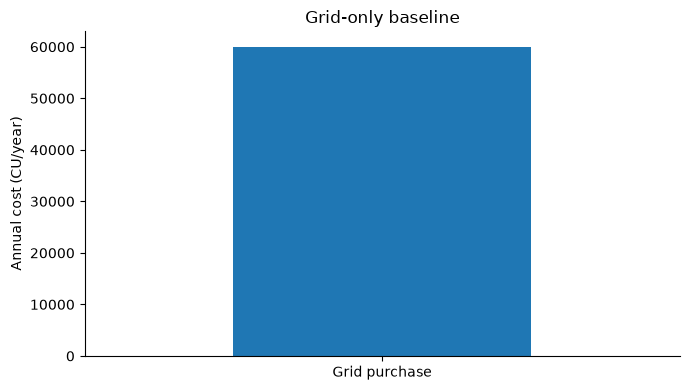

In [3]:
result = ou.extract_utility_system_result(
    model, case_study="tutorial", scenario="grid only"
)
assert math.isclose(pyo.value(model.grid_power_import), 100.0, abs_tol=1e-6)
assert math.isclose(result.total_annualized_cost, 60000.0, abs_tol=1e-6)
display(pd.DataFrame([asdict(result)]).T.rename(columns={0: "Value"}))
ax = pd.Series({"Grid purchase": result.total_annualized_cost}).plot.bar(rot=0)
ax.set(ylabel="Annual cost (CU/year)", title="Grid-only baseline")
plt.tight_layout()
plt.show()

## Try it

Change demand to 60 kW and calculate the new bill before solving. Adjust the import limit if you increase demand. Next: **02 Equipment selection** introduces investment decisions.